## Decision Tree

### Section 1: Theoretical Questions
**Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.**
- A Decision Tree is a supervised learning model that splits data into branches to make predictions.
  - **Root:** starting point (entire dataset)
  - **Decision nodes:** conditions that split data
  - **Leaf nodes:** final output (decision/class)
  - **Example:** Deciding a restaurant based on hunger and budget.

<br>

**Q2. Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-learn and why?**
$$
Gini Impurity = 1 - \sum P_i^2
$$
 
$$
Entropy = - \sum P_i \log_2(P_i)
$$

- **Gini Impurity:** faster to compute.
- **Entropy:** slower due to log.
- **Default in Scikit-learn:** Gini, because it is computationally efficient and gives similar results.

<br>

**Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?**
- Overfitting happens when the model learns noise instead of general patterns.
  - **Detection:** Very high training accuracy but much lower testing accuracy.

<br>

**Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?**
- Pruning reduces tree complexity to avoid overfitting.
  - **Pre-pruning:** Stop tree growth early (e.g., max depth)
  - **Post-pruning:** Grow full tree, then remove unnecessary branches

<br>

**Q5. What is Feature Importance? How can it help businesses in decision-making?**
- It shows how much each feature contributes to predictions.
  - **Business use:** Helps identify key factors, improve decisions, and focus on important variables.

### Section 2: Practical Questions (Hands-on using your dataset)

**Q6. Data Understanding**
- Load the dataset
- Display first 5 rows
- Check:
  - Shape
  - Data types
  - Column names

**Interpret:**
What types of variables are present?
- The dataset contains two main types of variables:
  - **Numerical variables (int64):** Quantitative features such as age, balance, day, duration, campaign, pdays, and previous.
  - **Categorical variables (object):** Qualitative features such as job, marital status, education, default, housing, loan, contact, month, and poutcome.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bank.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Check the shape (Rows, Columns)
print(f"\nShape of the dataset: {df.shape}")

# Display the data types of each column
print("\nData types per column:")
print(df.dtypes)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Shape of the dataset: (11162, 17)

Data types per column:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


**Q7. Data Cleaning**
- Check for missing values
- Handle missing values (if any)
- Check for duplicates

**Interpret:**
Is the dataset clean? What issues did you find?
- Yes, the dataset is clean. No missing values or duplicate records were found, so there are no data quality issues to address.

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Number of duplicate rows found: 0


**Q8. Data Preprocessing**
- Convert categorical variables into numerical
- Mention which encoding method you used

**Interpret:**
Why is encoding necessary for Decision Trees?
- Encoding is necessary because Decision Trees (in libraries like scikit-learn) require numerical input. It allows the model to perform mathematical operations, apply splitting rules (like ≤ thresholds), and process the data efficiently.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display updated data
print(df.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8      1042         1     -1         0         3        1  
1    5      8      1467         1     -1         0         3        1  
2    5      8      1389         1     -1         0         3        1  
3    5      8       579         1     -1         0         3        1  
4    5      8       673         2     -1         0         3        1  


**Q9. Feature Selection & Splitting**
- Separate:
- Features (X)
- Target (y)
- Perform train-test split (80-20)

**Interpret:**
Why is train-test split important?
- Train-test split is important because it allows evaluation on unseen data, helps detect overfitting, and provides an unbiased estimate of model performance.

In [5]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['deposit']) # Features: all columns except the target
y = df['deposit']                # Target: the variable we want to predict

# 2. Perform train-test split (80-20)
# test_size=0.2 indicates 20% for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 8929
Testing samples: 2233


**Q10. Model Building**
- Train a Decision Tree Classifier
- Use:
  - criterion='gini'
  - max_depth=5

**Interpret:**
What does max_depth control?
- max_depth controls the maximum number of levels a Decision Tree can grow, limiting its complexity to prevent overfitting, improve efficiency, and keep the model easier to interpret.

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# 2. Train the model using the training data
dt_clf.fit(X_train, y_train)

print("Decision Tree Classifier training complete.")

Decision Tree Classifier training complete.


**Q11. Model Evaluation**
- Perform:
  - Accuracy score
  - Confusion Matrix
  - Classification Report
  
**Interpret (MUST):**
Is the model performing well?
- Yes, the model performs well with about 80.5% accuracy.

Explain Precision & Recall?
- Precision (76%) means most predicted “yes” cases are correct, while Recall (87%) means the model identifies most actual “yes” cases.

Any class imbalance issue?
- No, the dataset is fairly balanced (≈52.6% “no”, 47.4% “yes”).

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = dt_clf.predict(X_test)

# Accuracy Score
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8051948051948052
Confusion Matrix:
 [[867 299]
 [136 931]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



**Q12. Overfitting Check**
Calculate:
Training accuracy
Testing accuracy

**Interpret**
Is the model overfitting or underfitting?
- The model is neither overfitting nor underfitting. Since the training and testing accuracies are very close (difference of about 1%), the model generalizes well to unseen data and does not simply memorize the training data.

In [8]:
from sklearn.metrics import accuracy_score

# 1. Calculate Training accuracy
# We use the model to predict outcomes for the data it was trained on
y_train_pred = dt_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# 2. Calculate Testing accuracy
# We use the model to predict outcomes for new, unseen data
y_test_pred = dt_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8150
Testing Accuracy: 0.8052


**Q13. Pruning Experiment**
- Train another model with:
  - max_depth=3
  - min_samples_split=20

**Interpret:**
Compare performance with previous model?
- The pruned model (76.5% accuracy) performs worse than the previous model (80.5% accuracy).

Which one is better and why?
- The original model (max_depth=5) is better because it captures patterns more effectively, while the pruned model underfits due to lower complexity.

In [9]:
# Train pruned model
dt_clf_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=20, random_state=42)
dt_clf_pruned.fit(X_train, y_train)

# Accuracy of pruned model
y_pred_pruned = dt_clf_pruned.predict(X_test)
print(f"Pruned Model Testing Accuracy: {accuracy_score(y_test, y_pred_pruned)}")

Pruned Model Testing Accuracy: 0.7653381101656964


**Q14. Feature Importance**
- Extract top 5 important features
- Plot feature importance graph

**Interpret:**
Which features influence prediction the most?
- The most influential feature is duration, followed by contact, pdays, housing, and month. This shows that call duration is the strongest factor in predicting whether a customer says “yes.”

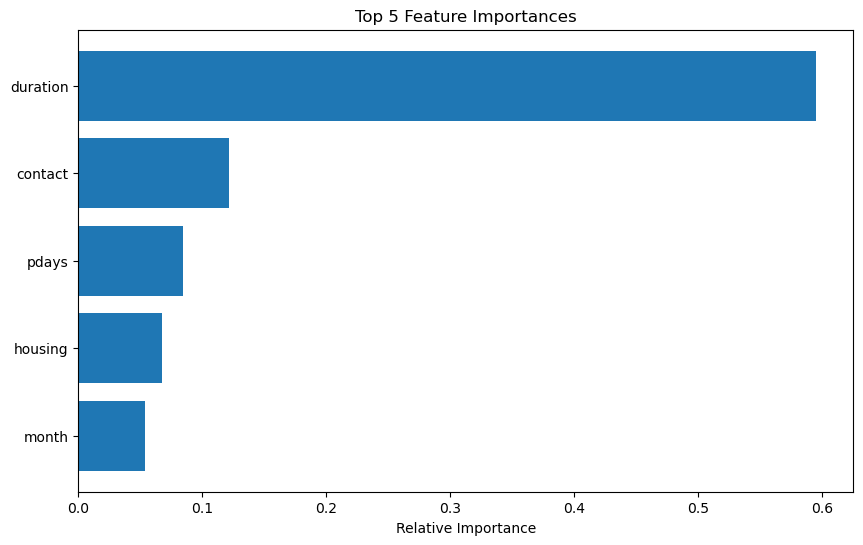

In [10]:
import numpy as np
import matplotlib.pyplot as plt

importances = dt_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-5:] # Top 5 features

plt.figure(figsize=(10, 6))
plt.title('Top 5 Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Q15. Business Insights**
Based on your model:

**Answer:**
**Which type of customers are more likely to say “yes”?**
- Customers who have longer call durations, no housing loan, and are successfully reached through effective contact methods are more likely to subscribe to the deposit. Also, customers with prior engagement (pdays) show higher chances of conversion.

**What strategy should a bank use?**
- The bank should focus on improving call quality to increase conversation duration, target customers with previous positive engagement, and prioritize individuals without existing financial liabilities like housing loans to improve conversion rates.
